In [141]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw

In [142]:
# product, time_reso, spatial_reso = 'IMERG', '1dy', 10
# product, time_reso, spatial_reso = 'CMORPH', '3h', 25
# product, time_reso, spatial_reso = 'MSWEP', '3h', 10
# product, time_reso, spatial_reso = 'ERA5', '3h', 25
# product, time_reso, spatial_reso = 'GSMaP', '3h', 10
product, time_reso, spatial_reso = 'CHIRPS', '1dy', 10

In [143]:
npix = 3
tscale = 24

In [144]:
# lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'Italy', 0.002
lon_min, lon_max, lat_min, lat_max, area, toll = 10.5, 13.5, 44.5, 47, 'Veneto', 0.002

In [145]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')

In [146]:
if product == 'IMERG':
    filename = 'IMERG_Italy_1dy_2000_06_01_2024_02_29.nc'

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'

else:
    sys.exit('Product not found')

In [147]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

PRE_study = DATA.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

lat_ref = PRE_study.lat.values
lon_ref = PRE_study.lon.values

del PRE_study

Product: CHIRPS


In [148]:
eps, alp = [], []
latc, lonc = [], []

for la in range(len(lat_ref)):#len(lat_ref)
    for lo in range(len(lon_ref)):#len(lon_ref)

        lat_c = lat_ref[la]
        lon_c = lon_ref[lo]

        box_3h = DOWN_raw.create_box_v2(DATA, lat_c, lon_c, npix)
        DAILY = box_3h.resample(time ='{}h'.format(tscale)).sum(dim='time', skipna=False)
        DAILY = DAILY.dropna(dim='time', how='all')

        try:
            rcorr = DOWN_raw.grid_corr(DAILY.PRE, plot=False, thresh=1, cor_method='pearson')
        
            eps.append(rcorr['eps_s'])
            alp.append(rcorr['alp_s'])
            latc.append(lat_c)
            lonc.append(lon_c)
        
        except:
            continue

pd_corr = pd.DataFrame({'lat':latc,'lon':lonc,'epsilon':eps,'alpha':alp})

In [149]:
dir_out = os.path.join('..','..','output','autocorr',f'{product}_Npix_{npix}_mar.csv')
print(f'Export dataframe to: {dir_out}')
pd_corr.to_csv(dir_out, header=True, index=False)

Export dataframe to: ../../output/autocorr/CHIRPS_Npix_3_mar.csv


Export figure to: ../../figures/autocorr/CHIRPS_Npix_3_mar.png


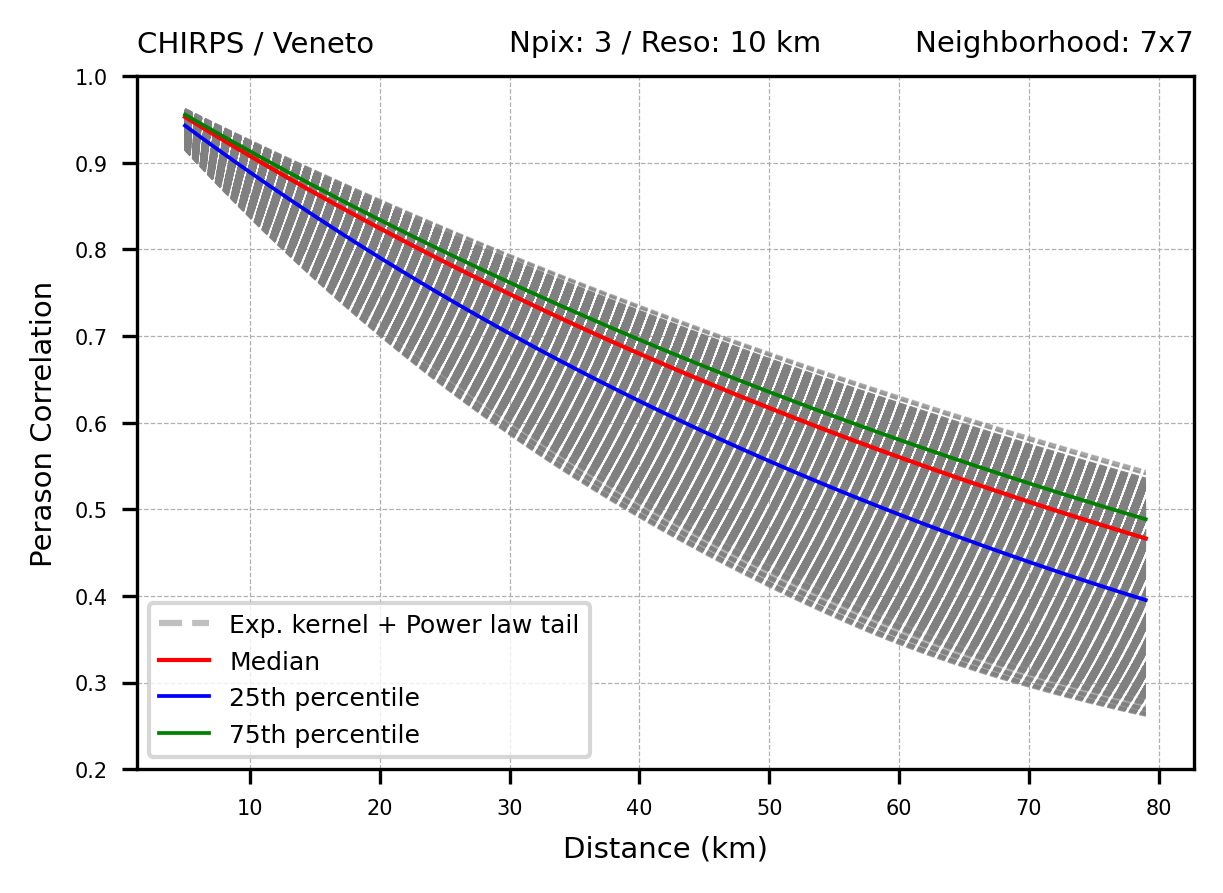

In [150]:
xx = np.arange(spatial_reso/2, spatial_reso*(npix*2+1)+spatial_reso)

fig = plt.figure(figsize=(10, 3), dpi=300)
gs = gridspec.GridSpec(1, 2)

#==========================================================================================================
ax1 = plt.subplot(gs[0, 0])
ax1.plot([],[], linestyle='--', color='grey', alpha=0.5, label='Exp. kernel + Power law tail')

todas_las_curvas = []
for nn in range(len(pd_corr)):
    y_vals = DOWN_raw.epl_fun(xx, pd_corr['epsilon'].iloc[nn], pd_corr['alpha'].iloc[nn])
    todas_las_curvas.append(y_vals)
    ax1.plot(xx, y_vals, linewidth=0.5, linestyle='--', color='grey', alpha=0.5)

matriz_curvas = np.array(todas_las_curvas)

median = np.median(matriz_curvas, axis=0)
p25 = np.percentile(matriz_curvas, 25, axis=0)
p75 = np.percentile(matriz_curvas, 75, axis=0)

ax1.plot(xx, median, linewidth=1, linestyle='-', color='red', label='Median')
ax1.plot(xx, p25, linewidth=0.9, linestyle='-', color='b', label='25th percentile')
ax1.plot(xx, p75, linewidth=0.9, linestyle='-', color='g', label='75th percentile')

ax1.tick_params(axis='both', which='major', labelsize=5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.legend(fontsize=6,loc=3)

ax1.set_title(f'{product} / {area}', loc='left', fontsize=7)
ax1.set_title(f'Npix: {npix} / Reso: {spatial_reso} km',loc='center',fontsize=7)
ax1.set_title(f'Neighborhood: {npix*2+1}x{npix*2+1}', loc='right', fontsize=7)
ax1.set_ylabel('Perason Correlation',fontsize=7)
ax1.set_xlabel('Distance (km)',fontsize=7)

ax1.set_ylim(0.2,1)

# ==========================================================================================================
salida = os.path.join('..','..','figures','autocorr',f'{product}_Npix_{npix}_mar.png')
print(f'Export figure to: {salida}')
plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)